In [1]:
import sys
sys.path.append('../functions')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from plotnine import *

In [3]:
def func(arg1, arg2, other_inputs):
    import pdb;pdb.set_trace()
    inside_func(k = 'k',**other_inputs)
    
def inside_func(k,a, b, c=1000):
    print(k)
    print(a)
    print(b)
    print(c)
    
func(1,2,{'b':1, 'a':3})

> <ipython-input-3-43abbf5b3583>(3)func()
      1 def func(arg1, arg2, other_inputs):
      2     import pdb;pdb.set_trace()
----> 3     inside_func(k = 'k',**other_inputs)
      4 
      5 def inside_func(k,a, b, c=1000):



ipdb>  c


k
3
1
1000


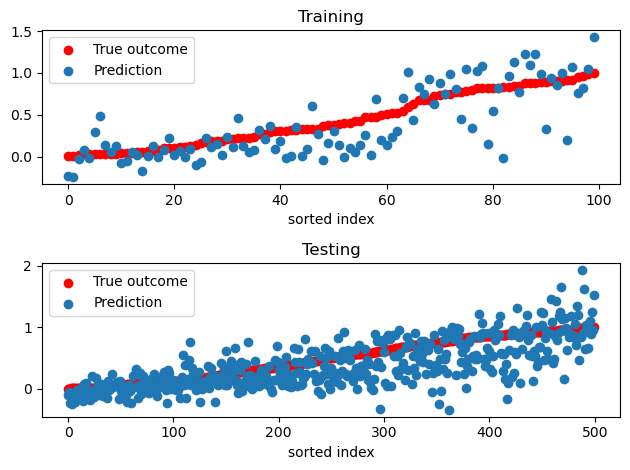

In [7]:
import pandas as pd
r

,contain,contain_scb,Lower_bound,Upper_bound,L1,L2,U1,U2,points_in_e1,inner_points_num,outer_points_num,true_set_points_num,model,on_y
0,True,True,0.9,0.985,0.805,0.9,0.985,0.995,21,106,391,225,<class 'models.logistic_regression'>,0


In [5]:
import sys
sys.path.append('../functions')
import multiprocessing
import numpy as np
import pandas as pd
import time
from datetime import date
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import torch
# custom functions
from CS_sim_helper import sim_CS_wrapper, generate_sim_data,check_overfitting, transform_X_poly,transform_X
from models import NueralNet, logistic_regression

today = date.today()
date = today.strftime("%d%m%Y")
file_name = 'test'+date+'.csv'
if __name__ ==  '__main__': 
    df_total = pd.DataFrame()
    n_sim = 2
    L_v = [0.9]
    level_v = [0]
    models_l_v = [[LinearRegression]]
    models_kwargs_l_v = [[{}]]
    N_v = [100]
    N_test_v = [500]
    p_v = [2]
    error_sd_v = [1]
    data_sim_func_v = [generate_sim_data]
    data_kwargs_v = [{}]
    center_G_v = [True]
    center_pred_v = [False]
    use_true_contour_v = [False]
    n_boot_v = [200]
    df_result = []
    param_grid = {'L': L_v, 'level': level_v, 'models_l': models_l_v,'model_kwargs_l':models_kwargs_l_v,
                  'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 
                  'data_sim_func':data_sim_func_v, 'data_kwargs':data_kwargs_v,
                  'center_G':center_G_v, 'center_pred':center_pred_v, 'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v
                 }
    param_grid = ParameterGrid(param_grid)
    start = time.time()
    for param in param_grid:
        para_name_dict = {k:str(v) for k, v in param.items()}
        df = pd.DataFrame(para_name_dict, index = [0])
        ctx = torch.multiprocessing.get_context('spawn')
        pool_obj = ctx.Pool()
        # pool_obj = multiprocessing.Pool()
        # cur_para = (n_sim*(param,))
        #import pdb; pdb.set_trace()
        df_ = pd.concat(pool_obj.map(sim_CS_wrapper, cur_para)).reset_index(drop = True)
        pool_obj.close()
        pool_obj.join()
        para_df = pd.DataFrame(np.repeat(df.values,df_.shape[0], axis=0))
        para_df.columns = df.columns
        df_ = pd.concat([para_df, df_], axis = 1)
        df_total = pd.concat([df_total,df_])
        df_total.to_csv(file_name, index = False)
    end = time.time()
    print('Runtime of the program is ' + str(end -start) + ' seconds')


Runtime of the program is 4.269744873046875 seconds


# Linear regression

In [7]:
sim_result = pd.read_csv('../functions/sim_results_ridge_test14012023.csv')
sim_result.mean()

L                         0.950000
N                       150.000000
N_test                  500.000000
error_sd                  2.500000
level                     0.200000
n_boot                 2000.000000
p                       160.000000
ridge                     1.000000
use_true_contour          0.000000
contain                   0.838800
contain_scb               0.457200
contain_CS_scb            0.943400
Lower_bound               0.950006
Upper_bound               0.982473
L1                        0.836059
L2                        0.950006
U1                        0.982473
U2                        0.998652
points_in_e1             50.726400
pre_mae                   5.571138
inner_points_num         19.609000
outer_points_num        478.689800
true_set_points_num     246.924200
dtype: float64

In [36]:
# Confidence set
sim_result = pd.read_csv('../functions/sim_results_Ridge_true_contour27012023.csv')
sim_result

,CV_boot,L,MC,N,N_test,center_G,error_sd,level,n_boot,p,...,L1,L2,U1,U2,points_in_e1,pre_mae,pre_mse,inner_points_num,outer_points_num,true_set_points_num
0,True,0.9,False,30,500,False,1,0.2,2000,50,...,0.1460,0.8990,0.9615,1.0000,39.0,3.569233,21.125544,39.0,461.0,176.0
1,True,0.9,False,30,500,False,1,0.2,2000,50,...,0.2395,0.9045,0.9740,0.9935,29.0,3.634817,20.019377,29.0,474.0,295.0
2,True,0.9,False,30,500,False,1,0.2,2000,50,...,0.1210,0.8975,0.9840,1.0000,54.0,4.629688,34.068383,39.0,479.0,249.0
3,True,0.9,False,30,500,False,1,0.2,2000,50,...,0.3620,0.8985,0.9715,0.9945,59.0,4.384011,30.760266,37.0,488.0,239.0
4,True,0.9,False,30,500,False,1,0.2,2000,50,...,0.1755,0.8985,0.9740,0.9965,28.0,3.245320,16.533031,52.0,476.0,269.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,True,0.9,False,30,500,True,1,0.2,2000,50,...,0.7370,0.9010,0.9640,0.9955,40.0,3.566968,19.712907,37.0,459.0,219.0
1996,True,0.9,False,30,500,True,1,0.2,2000,50,...,0.6665,0.8980,0.9660,0.9930,42.0,3.936772,24.357125,91.0,481.0,282.0
1997,True,0.9,False,30,500,True,1,0.2,2000,50,...,0.6505,0.8990,0.9650,0.9930,23.0,3.703727,21.413476,52.0,425.0,255.0
1998,True,0.9,False,30,500,True,1,0.2,2000,50,...,0.5415,0.8985,0.9615,0.9960,22.0,3.763575,22.277591,45.0,427.0,257.0


In [23]:
#sim_result = sim_result[sim_result.ridge_penal!=0.1]
sim_result = sim_result[sim_result.contain != -1]
sim_result
#sim_result.groupby(['N', 'N_test', 'p', 'MC',  'use_true_contour','CV_boot','n_boot']).mean()

,CV_boot,L,MC,N,N_test,center_G,error_sd,level,n_boot,p,...,L1,L2,U1,U2,points_in_e1,pre_mae,pre_mse,inner_points_num,outer_points_num,true_set_points_num


In [34]:
sim_result = sim_result[sim_result.contain != -1]
sim_result = sim_result[sim_result.use_true_contour == 0]
sim_result = sim_result[sim_result.ridge_penal==0.1]

In [38]:
sim_result.groupby(['N', 'N_test', 'p', 'MC', 'center_G', 'use_true_contour','CV_boot','n_boot']).mean()

/tmp/ipykernel_479/3473567898.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sim_result.groupby(['N', 'N_test', 'p', 'MC', 'center_G', 'use_true_contour','CV_boot','n_boot']).mean()


L  error_sd  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot                  
30 500    50 False False    False            True    2000    0.9       1.0   
                            True             True    2000    0.9       1.0   
                   True     False            True    2000    0.9       1.0   
                            True             True    2000    0.9       1.0   

                                                             level  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot          
30 500    50 False False    False            True    2000      0.2   
                            True             True    2000      0.2   
                   True     False            True    2000      0.2   
                            True             True    2000      0.2   

                                                             residual_boot  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot                  
30 500    50 False False    False            True    2000              0.0   
                            True             True    2000              0.0   
                   True     False            True    2000              0.0   
                            True             True    2000              0.0   

                                                             smoothed  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot             
30 500    50 False False    False            True    2000         0.0   
                            True             True    2000         0.0   
                   True     False            True    2000         0.0   
                            True             True    2000         0.0   

                                                             contain  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot            
30 500    50 False False    False            True    2000      0.202   
                            True             True    2000      0.412   
                   True     False            True    2000      0.082   
                            True             True    2000      0.068   

                                                             contain_scb  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot                
30 500    50 False False    False            True    2000          0.068   
                            True             True    2000          0.094   
                   True     False            True    2000          0.008   
                            True             True    2000          0.000   

                                                             contain_CS_scb  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot                   
30 500    50 False False    False            True    2000             0.908   
                            True             True    2000             0.900   
                   True     False            True    2000             0.376   
                            True             True    2000             0.402   

                                                             Lower_bound  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot                
30 500    50 False False    False            True    2000       0.900292   
                            True             True    2000       0.900058   
                   True     False            True    2000       0.899965   
                            True             True    2000       0.899849   

                                                             Upper_bound  \
N  N_test p  MC    center_G use_true_contour CV_boot n_boot                
30 500    50 False False    False            True    2000       0.971540   
                            True             True    2000       0.964036   
                   True     False            True    2000       0.966300   
                            True             True    2000      

In [50]:
df_plot = sim_result.groupby(['N', 'N_test', 'p', 'error_sd', 'level', 'use_true_contour']).mean().reset_index()
df_plot['group'] = 'Number of Covariates:'+df_plot["p"].astype(str)+'; '+ 'Noise SD: '+df_plot["error_sd"].astype(str)

In [51]:
df_plot = df_plot[df_plot.error_sd!=2]
df_plot = df_plot[np.logical_or(df_plot.p == 9,df_plot.p == 159)]

In [52]:
df_plot["p"] = df_plot["p"].astype("category")
df_plot["error_sd"] = df_plot["error_sd"].astype("category")

In [142]:
df_plot

,N,N_test,p,error_sd,level,use_true_contour,contain,contain_scb,contain_CS_scb,Lower_bound,...,L1,L2,U1,U2,points_in_e1,pre_mae,inner_points_num,outer_points_num,true_set_points_num,group
0,50.0,500.0,9.0,1.0,0.2,0.0,0.978,0.946,0.998,0.950000,...,0.899196,0.949764,0.982024,0.996480,12.098,0.395076,140.518,337.900,236.478,Number of Covariates:9.0; Noise SD: 1.0
2,50.0,500.0,9.0,4.0,0.2,0.0,0.986,0.966,0.998,0.950000,...,0.938064,0.943056,0.982900,0.998520,35.902,1.552051,12.216,482.496,236.734,Number of Covariates:9.0; Noise SD: 4.0
9,50.0,500.0,159.0,1.0,0.2,0.0,0.866,0.000,0.990,0.950000,...,0.828216,0.950000,0.983892,0.999316,46.460,8.440065,1.814,497.348,245.804,Number of Covariates:159.0; Noise SD: 1.0
11,50.0,500.0,159.0,4.0,0.2,0.0,0.834,0.000,0.984,0.950000,...,0.820128,0.950000,0.983636,0.999356,46.204,8.676118,1.718,497.488,245.702,Number of Covariates:159.0; Noise SD: 4.0
18,150.0,500.0,9.0,1.0,0.2,0.0,0.970,0.924,0.998,0.950000,...,0.796696,0.950000,0.979568,0.992436,4.916,0.207505,191.364,278.196,234.074,Number of Covariates:9.0; Noise SD: 1.0
20,150.0,500.0,9.0,4.0,0.2,0.0,0.936,0.886,0.992,0.950000,...,0.889012,0.949984,0.981648,0.997428,15.930,0.839924,79.204,407.992,240.820,Number of Covariates:9.0; Noise SD: 4.0
27,150.0,500.0,159.0,1.0,0.2,0.0,1.000,1.000,1.000,0.950000,...,0.504548,0.950000,0.984016,0.999372,33.764,4.056098,5.384,494.536,247.982,Number of Covariates:159.0; Noise SD: 1.0
29,150.0,500.0,159.0,4.0,0.2,0.0,0.408,0.994,1.000,0.949380,...,0.016624,0.949380,0.987552,0.999600,30.398,13.161498,14.128,485.428,247.732,Number of Covariates:159.0; Noise SD: 4.0
36,250.0,500.0,9.0,1.0,0.2,0.0,0.960,0.930,1.000,0.950000,...,0.759332,0.950000,0.978528,0.990816,3.970,0.159126,205.446,271.656,237.910,Number of Covariates:9.0; Noise SD: 1.0
38,250.0,500.0,9.0,4.0,0.2,0.0,0.962,0.916,0.994,0.950000,...,0.868556,0.950000,0.981124,0.996868,11.986,0.633202,104.586,370.704,233.956,Number of Covariates:9.0; Noise SD: 4.0


In [145]:
table_temp = df_plot[np.logical_and(df_plot.error_sd == 1, df_plot.p == 9)].pivot(index = ['N'], columns = [], 
                           values = ['inner_points_num', 'outer_points_num', 'points_in_e1', 'Lower_bound', 'contain','Upper_bound'])

In [149]:
table_temp = table_temp.round(3)
table_temp

,inner_points_num,outer_points_num,points_in_e1,Lower_bound,contain,Upper_bound
N,,,,,,
50.0,140.518,337.900,12.098,0.95,0.978,0.982
150.0,191.364,278.196,4.916,0.95,0.970,0.980
250.0,205.446,271.656,3.970,0.95,0.960,0.978
500.0,213.714,255.820,2.868,0.95,0.940,0.977
1000.0,223.918,252.464,2.256,0.95,0.958,0.975


In [150]:
print(table_temp.to_latex())

\begin{tabular}{lrrrrrr}
\toprule
       &  inner\_points\_num &  outer\_points\_num &  points\_in\_e1 &  Lower\_bound &  contain &  Upper\_bound \\
N &                   &                   &               &              &          &              \\
\midrule
50.0   &           140.518 &           337.900 &        12.098 &         0.95 &    0.978 &        0.982 \\
150.0  &           191.364 &           278.196 &         4.916 &         0.95 &    0.970 &        0.980 \\
250.0  &           205.446 &           271.656 &         3.970 &         0.95 &    0.960 &        0.978 \\
500.0  &           213.714 &           255.820 &         2.868 &         0.95 &    0.940 &        0.977 \\
1000.0 &           223.918 &           252.464 &         2.256 &         0.95 &    0.958 &        0.975 \\
\bottomrule
\end{tabular}



/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: results/coverage_plot_linear.png


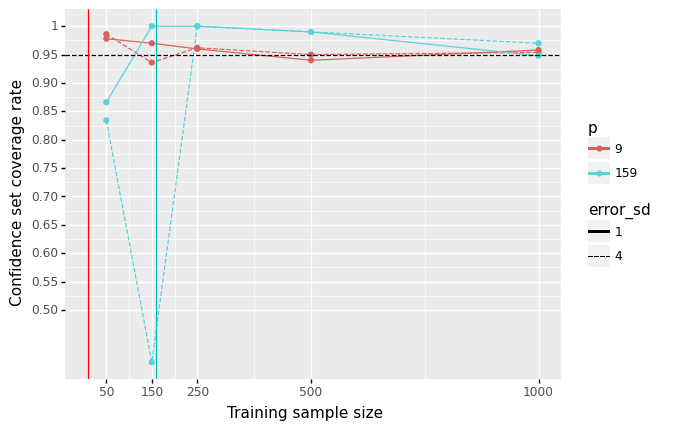

In [141]:
coverage_plot = (ggplot(df_plot)+
 geom_line(aes(x = 'N', y = 'contain', color = 'p', linetype = 'error_sd'))+
 geom_point(aes(x = 'N', y = 'contain', color = 'p'))+
 #geom_ribbon(aes(x = 'N',ymin='Lower_bound', ymax='Upper_bound',fill = 'p'), alpha=0.1)+
 #ylim(0.5, 1)+
 geom_hline(yintercept = 0.95,  linetype="dashed", color = "black")+
 geom_vline(xintercept = 159,  color="#00BFC4", linetype = 'solid')+
 geom_vline(xintercept = 9,  color="red", linetype = 'solid')+
 scale_x_continuous(breaks=np.array(df_plot.N[~df_plot.N.duplicated()]))+
 scale_y_continuous(breaks=[0, 0.5, 0.55, 0.6,0.65, 0.7,0.75,0.8,0.85, 0.9,0.95, 1])+
 ylab('Confidence set coverage rate')+
 xlab('Training Sample size')
)
coverage_plot.save('results/coverage_plot_linear.png',dpi = 300)
coverage_plot.draw()

Simulation variance horizontal line.
Where sample size equal to p.

# Neural network

In [36]:
sim_result = pd.read_csv('sim_NN_results_23112022.csv')


In [37]:
sim_result.columns


Index(['0', 'contain', 'N', 'N_test', 'p', 'error_sd', 'level',
       'use_true_contour', 'contain_scb', 'contain_CS_scb', 'Lower_bound',
       'Upper_bound', 'L1', 'L2', 'U1', 'U2', 'points_in_e1', 'pre_mae',
       'inner_points_num', 'outer_points_num', 'true_set_points_num'],
      dtype='object')

In [39]:
print(sim_result[['contain', 'N', 'p', 'contain_scb', 'inner_points_num', 'outer_points_num', 'points_in_e1']].groupby(['N', 'p']).mean().to_latex())

\begin{tabular}{llrrrrr}
\toprule
      &     &  contain &  contain\_scb &  inner\_points\_num &  outer\_points\_num &  points\_in\_e1 \\
N & p &          &              &                   &                   &               \\
\midrule
50.0  & 2.0 &    0.924 &        0.484 &            81.676 &           423.758 &        42.892 \\
      & 4.0 &    0.948 &        0.594 &            30.964 &           465.798 &        61.254 \\
100.0 & 2.0 &    0.944 &        0.458 &           121.498 &           375.128 &        27.352 \\
      & 4.0 &    0.966 &        0.628 &            65.668 &           434.600 &        36.830 \\
200.0 & 2.0 &    0.892 &        0.370 &           158.314 &           345.722 &        20.384 \\
      & 4.0 &    0.938 &        0.498 &           104.660 &           396.230 &        26.162 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_89/3349944937.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


# Interpretation of black box algorithms

In [33]:
sim_inter_result = pd.read_csv('sim_results_interpretation25112022.csv')


In [45]:
temp_table = sim_inter_result.loc[sim_inter_result.N!=50, ['N', 'p', 'N_test','contain', 'all_causal', 'percent_causal_selected']].groupby(['N', 'p', 'N_test']).mean()


In [46]:
print(temp_table.to_latex())# This for p_casual=20

\begin{tabular}{lllrrr}
\toprule
      &      &        &  contain &  all\_causal &  percent\_causal\_selected \\
N & p & N\_test &          &             &                          \\
\midrule
100.0 & 50.0 & 200.0  &    1.000 &       1.000 &                   0.0122 \\
      &      & 500.0  &    1.000 &       1.000 &                   0.0602 \\
      &      & 1000.0 &    1.000 &       0.998 &                   0.1171 \\
200.0 & 50.0 & 200.0  &    0.984 &       1.000 &                   0.1073 \\
      &      & 500.0  &    0.984 &       1.000 &                   0.2935 \\
      &      & 1000.0 &    0.976 &       0.992 &                   0.4238 \\
\bottomrule
\end{tabular}



In [27]:
df_plot = sim_inter_result.groupby(['N', 'p', 'p_causal']).mean().reset_index()
df_plot["p"] = df_plot["p"].astype("category")
df_plot = df_plot[df_plot.p==50]

In [28]:
df_plot

,N,p,p_causal,contain,all_causal,percent_causal_selected,N_test,error_sd,level,L
0,200.0,50.0,10.0,0.978,0.990,0.4312,500.0,1.0,0.0,0.95
1,200.0,50.0,20.0,0.988,1.000,0.3090,500.0,1.0,0.0,0.95
4,400.0,50.0,10.0,0.944,0.998,0.4704,500.0,1.0,0.0,0.95
5,400.0,50.0,20.0,0.962,1.000,0.3031,500.0,1.0,0.0,0.95


In [29]:
df_plot = pd.melt(df_plot, id_vars=['N', 'p', 'p_causal'], value_vars= ['all_causal', 'percent_causal_selected'], var_name= 'Type', value_name='Percentage')
df_plot["p_causal"] = df_plot["p_causal"].astype("category")

In [30]:
df_plot

,N,p,p_causal,Type,Percentage
0,200.0,50.0,10.0,all_causal,0.9900
1,200.0,50.0,20.0,all_causal,1.0000
2,400.0,50.0,10.0,all_causal,0.9980
3,400.0,50.0,20.0,all_causal,1.0000
4,200.0,50.0,10.0,percent_causal_selected,0.4312
5,200.0,50.0,20.0,percent_causal_selected,0.3090
6,400.0,50.0,10.0,percent_causal_selected,0.4704
7,400.0,50.0,20.0,percent_causal_selected,0.3031


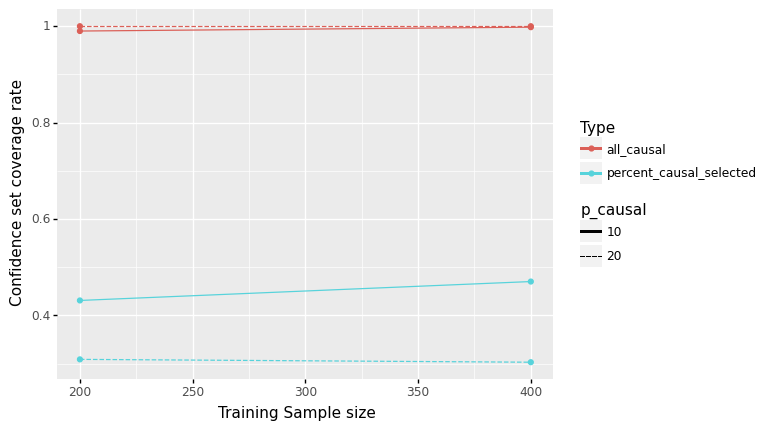

In [32]:
coverage_plot = (ggplot(df_plot)+
 geom_line(aes(x = 'N', y = 'Percentage', color = 'Type', linetype = 'p_causal'))+
 geom_point(aes(x = 'N', y = 'Percentage', color = 'Type'))+
 #geom_ribbon(aes(x = 'N',ymin='Lower_bound', ymax='Upper_bound',fill = 'p'), alpha=0.1)+
 #ylim(0.5, 1)+
 # scale_x_continuous(breaks=np.array(df_plot.N[~df_plot.N.duplicated()]))+
 # scale_y_continuous(breaks=[0, 0.5, 0.55, 0.6,0.65, 0.7,0.75,0.8,0.85, 0.9,0.95, 1])+
 ylab('Confidence set coverage rate')+
 xlab('Training Sample size')
)
#coverage_plot.save('results/coverage_plot_linear.png',dpi = 300)
coverage_plot.draw()